In [1]:
import os
# os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

import sys

sys.path.insert(0, "../..")

In [2]:
import chex
import dill
import jax
import jax.numpy as jnp
import json
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd

from flax import nnx
from torch.utils.data import DataLoader
from typing import Any, NamedTuple
from typing_extensions import Protocol, runtime_checkable

from src.dataset import get_iter
from src.datasets.sum import Addition
from src.decoding import make_autoregressive
from src.utils import parse_dict
from src.verifier import make_compute_returns

## Helpers

In [3]:
class StepState(NamedTuple):
    graphdef: Any
    rest: Any
    cache: Any
    eos_token: int
    rng: chex.PRNGKey
    sequence: chex.Array
    is_prompt: chex.Array
    eos: chex.Array
    logits: chex.Array
    step_i: int = 0
    deterministic: int = 0


def predict_step(
    step_state: StepState,
):
    step_i = step_state.step_i
    rng, rng_step = jax.random.split(step_state.rng, 2)

    # Autoregressively decode
    module = nnx.merge(step_state.graphdef, step_state.rest, step_state.cache)
    module.eval()
    module.set_attributes(deterministic=True, decode=True)
    logits = module({"sequence": step_state.sequence[:, [step_i]],},)
    cache = nnx.state(module, nnx.Cache)

    logits = logits[:, 0]

    output_tokens = jax.lax.cond(
        step_state.deterministic,
        lambda rng_step, logits: jnp.argmax(logits, axis=-1),
        jax.random.categorical,
        rng_step,
        logits,
    )

    # Check for prompt boundary
    is_prompt = step_state.is_prompt[:, step_i]

    output_tokens = jnp.where(
        is_prompt,
        step_state.sequence[:, step_i + 1],
        output_tokens,
    )

    # Check if the first EOS has been generated
    eos = jnp.logical_or(
        output_tokens == step_state.eos_token,
        step_state.eos[:, step_i],
    )

    # Update the entries on the i'th step
    sequence = step_state.sequence.at[:, step_i + 1].set(output_tokens)
    eos = step_state.eos.at[:, step_i + 1].set(eos)
    all_logits = step_state.logits.at[:, step_i + 1].set(logits)

    step_state = StepState(
        graphdef=step_state.graphdef,
        rest=step_state.rest,
        cache=cache,
        eos_token=step_state.eos_token,
        rng=rng,
        sequence=sequence,
        is_prompt=step_state.is_prompt,
        eos=eos,
        step_i=step_i + 1,
        deterministic=step_state.deterministic,
        logits=all_logits,
    )

    return step_state

@nnx.jit(static_argnames=["out_dim"])
def rollout(
    graphdef: Any,
    cache: Any,
    rest: Any,
    rng: chex.PRNGKey,
    batch: Any,
    out_dim: int,
    eos_token: int,
    deterministic: int = 0,
):
    questions = batch["sequence"]
    mask = batch["mask"]
    num_questions, max_step = questions.shape

    step_state = StepState(
        graphdef=graphdef,
        rest=rest,
        cache=cache,
        eos_token=eos_token,
        rng=rng,
        sequence=questions,
        is_prompt=1 - mask,
        eos=jnp.zeros((num_questions, max_step)),
        logits=jnp.zeros((num_questions, max_step, out_dim)),
        deterministic=deterministic,
    )

    step_state = jax.lax.while_loop(
        lambda state: state.step_i < max_step - 1,
        predict_step,
        step_state,
    )

    return {
        "response": step_state.sequence,
        "eos": step_state.eos,
        "is_prompt": step_state.is_prompt,
        "logits": step_state.logits,
    }


In [4]:
Dtype = Any
Shape = tuple[int, ...]
EOS_TOKEN = 4

@runtime_checkable
class HasCache(Protocol):
    def init_cache(self, input_shape: Shape, dtype: Dtype = jnp.float32): ...

def evaluate(
    learner_path,
    batch,
    out_dim,
    batch_size,
    eval_seed,
    num_evals,
    max_decode_len,
    dtype,
    checkpoint_i=-1,
    stochastic=False,
):
    config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))

    # Load model
    last_step = sorted(os.listdir(os.path.join(learner_path, "models")))[checkpoint_i]
    train_state = dill.load(
        open(os.path.join(learner_path, "models", last_step), "rb")
    )

    # print(train_state.params)
    model = nnx.merge(
        train_state.graphdef,
        train_state.params,
        train_state.rest,
    )

    rng = jax.random.PRNGKey(eval_seed)
    rng, rollout_rng = jax.random.split(rng)

    # Sample next batch and evaluate
    _, init_cache = make_autoregressive(
        model,
        max_decode_len=max_decode_len,
        batch_size=batch_size * num_evals,
        embed_dim=config_dict["model_config"]["model_kwargs"]["embed_dim"],
        dtype=dtype,
        eval_mode=True,
    )
    cache = init_cache()
    graphdef, _, rest = nnx.split(model, nnx.Cache, ...)

    rollout_res = rollout(
        graphdef,
        cache,
        rest,
        rollout_rng,
        batch,
        out_dim=out_dim,
        eos_token=EOS_TOKEN,
        deterministic=1 - int(stochastic),
    )

    return rollout_res

## Evaluate

In [5]:
base_path = "/home/bryanpu1/projects/iclr_2026/icl_architecture/scaling_jax/results"

algo_name = "addition-debug_no_eos"
run_name = "ppo-test-max_int_64-scratch-64_rollouts-09-11-25_09_30_35-96129b62-66f9-4fbf-a96f-63e40b8977b5"
run_name = "ppo-test-left_to_right-max_int_64-scratch-64_rollouts-09-15-25_08_10_08-310bcedb-cd3a-4f64-89cb-d6d1222d6760"
run_name = "ppo-test-max_int_64-load_from_64-bs_512-09-13-25_18_58_50-227355d3-e9a6-4586-b178-b42b7ad7a1f3"
run_name = "ppo-test-max_int_64-load_from_64-parallel_64-09-13-25_18_59_27-fdc16a0c-c1f7-4438-b1b9-e831a70c2c4a"

learner_path = os.path.join(base_path, algo_name, run_name)

In [6]:
save_filename = f"res-{run_name}.dill"

eval_seed = 42
num_evals = 5
max_batch_size = 200
max_decode_len = 200

config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))
half_precision = config_dict["half_precision"]
dtype = jnp.bfloat16 if half_precision else jnp.float32

# Get dataset
config_dict["dataset_kwargs"]["max_int"] = 256
config = parse_dict(config_dict)
dataset_kwargs = config.dataset_kwargs

num_checkpoints = len(os.listdir(os.path.join(learner_path, "models")))
if os.path.isfile(save_filename):
    print("Loaded from storage")
    all_res = dill.load(open(save_filename, "rb"))
else:
    all_res = dict(
        results=dict(),
        metrics=dict(),
    )

    print(f"Max decode len: {max_decode_len}")
    max_num_bits = int(np.ceil(np.log2(dataset_kwargs.max_int)))
    for num_bits in range(1, max_num_bits + 1):
        curr_int = 2 ** num_bits
        num_pairs = curr_int * curr_int
        num_val = num_pairs - int(np.floor(num_pairs * dataset_kwargs.train_val_ratio))
        batch_size = min(num_val, max_batch_size)
        dataset = Addition(
            context_len=max_decode_len,
            max_int=curr_int,
            train=False,
            seed=eval_seed,
            sequence_type="question_only",
            train_val_ratio=dataset_kwargs.train_val_ratio,
            right_to_left=getattr(dataset_kwargs, "right_to_left", False),
            shuffle=False,
            exact=True,
            predict_eos=getattr(dataset_kwargs, "predict_eos", True),
        )

        compute_returns = make_compute_returns(config, EOS_TOKEN)

        print(f"Max int: {curr_int}, batch size: {batch_size}")

        out_dim = int(dataset.output_space.n)
        data_loader = DataLoader(
            dataset,
            batch_size=batch_size,
            num_workers=0,
        )
        data_iter = get_iter(data_loader, None, dtype)
        batch = next(data_iter)
        batch = {
            "sequence": np.repeat(batch["sequence"], num_evals, axis=0),
            "mask": np.repeat(batch["mask"], num_evals, axis=0),
            "target": np.repeat(batch["target"], num_evals, axis=0),
        }

        for checkpoint_i in range(num_checkpoints):
            all_res["results"].setdefault(checkpoint_i, dict())
            all_res["metrics"].setdefault(checkpoint_i, dict())

            all_res["results"][checkpoint_i][num_bits] = evaluate(
                learner_path=learner_path,
                batch=batch,
                out_dim=out_dim,
                batch_size=batch_size,
                eval_seed=eval_seed,
                num_evals=num_evals,
                max_decode_len=max_decode_len,
                dtype=dtype,
                checkpoint_i=checkpoint_i,
                stochastic=True,
            )

            returns, successes, response_lengths = compute_returns(
                {
                    "target": batch["target"],
                    "sequence": all_res["results"][checkpoint_i][num_bits]["response"]
                },
                all_res["results"][checkpoint_i][num_bits]["eos"],
                all_res["results"][checkpoint_i][num_bits]["is_prompt"],
                is_eval=False,
            )

            all_res["metrics"][checkpoint_i][num_bits] = {
                "successes": successes.reshape((batch_size, num_evals)),
                "response_lengths": response_lengths.reshape((batch_size, num_evals)),
            }
    dill.dump(all_res, open(save_filename, "wb"))

Max decode len: 200
Max int: 2, batch size: 1
Max int: 4, batch size: 2
Max int: 8, batch size: 7
Max int: 16, batch size: 26
Max int: 32, batch size: 103
Max int: 64, batch size: 200
Max int: 128, batch size: 200
Max int: 256, batch size: 200


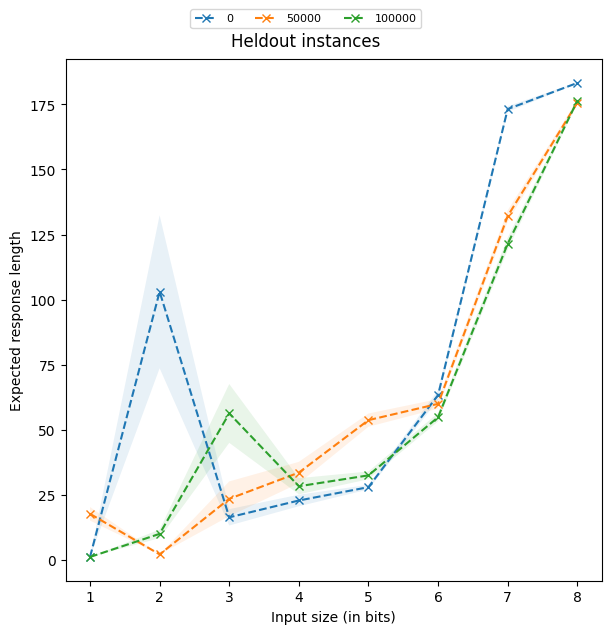

In [7]:
fig, ax = plt.subplots(1, 1, layout="constrained", figsize=(6, 6))


skip_step = 10
checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(all_res["metrics"].keys()))
# checkpoints = [0, 2, 5, 10, 19, 20]
for checkpoint_i, curr_metric in all_res["metrics"].items():
    if (
        checkpoint_i != last_checkpoint
        and checkpoint_i > 0
        and checkpoint_i % skip_step != 0
    ):
    # if checkpoint_i not in checkpoints:
        continue

    input_length_range = sorted(curr_metric.keys())
    expected_response_lengths = []
    for num_bits in input_length_range:
        expected_response_lengths.append((
            np.mean(curr_metric[num_bits]["response_lengths"]),
            np.std(curr_metric[num_bits]["response_lengths"]) / np.sqrt(
                curr_metric[num_bits]["response_lengths"].shape[0]
                * curr_metric[num_bits]["response_lengths"].shape[1]
            ),
        ))

    expected_response_lengths = np.array(expected_response_lengths)

    ax.plot(
        input_length_range,
        expected_response_lengths[:, 0],
        marker="x",
        linestyle="--",
        label=f"{checkpoint_i * checkpoint_interval}",
    )
    ax.fill_between(
        input_length_range,
        expected_response_lengths[:, 0] + expected_response_lengths[:, 1],
        expected_response_lengths[:, 0] - expected_response_lengths[:, 1],
        alpha=0.1,
    )
    ax.set_xticks(input_length_range)
    ax.set_ylabel("Expected response length")
    ax.set_xlabel("Input size (in bits)")

fig.suptitle("Heldout instances")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

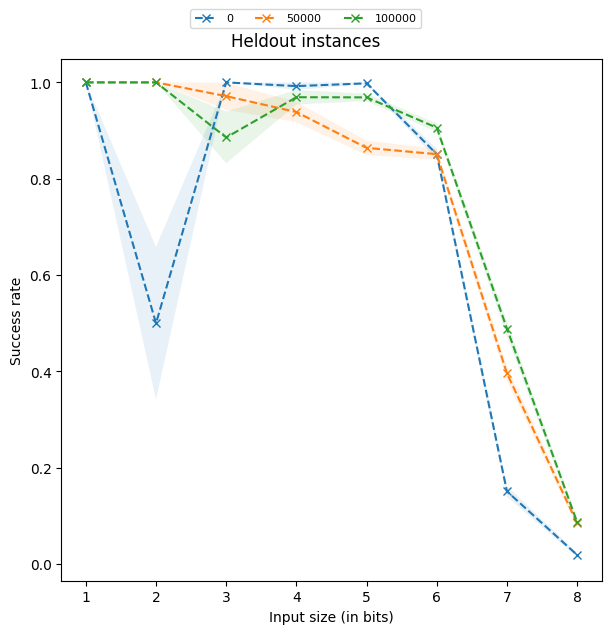

In [8]:
fig, ax = plt.subplots(1, 1, layout="constrained", figsize=(6, 6))

skip_step = 10
checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(all_res["metrics"].keys()))
for checkpoint_i, curr_metric in all_res["metrics"].items():
    if (
        checkpoint_i != last_checkpoint
        and checkpoint_i > 0
        and checkpoint_i % skip_step != 0
    ):
        continue

    input_length_range = sorted(curr_metric.keys())
    expected_successes = []
    for num_bits in input_length_range:
        expected_successes.append((
            np.mean(curr_metric[num_bits]["successes"]),
            np.std(curr_metric[num_bits]["successes"]) / np.sqrt(
                curr_metric[num_bits]["successes"].shape[0]
                * curr_metric[num_bits]["successes"].shape[1]
            ),
        ))

    expected_successes = np.array(expected_successes)

    ax.plot(
        input_length_range,
        expected_successes[:, 0],
        marker="x",
        linestyle="--",
        label=f"{checkpoint_i * checkpoint_interval}",
    )
    ax.fill_between(
        input_length_range,
        expected_successes[:, 0] + expected_successes[:, 1],
        expected_successes[:, 0] - expected_successes[:, 1],
        alpha=0.1,
    )
    ax.set_xticks(input_length_range)
    ax.set_ylabel("Success rate")
    ax.set_xlabel("Input size (in bits)")

fig.suptitle("Heldout instances")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

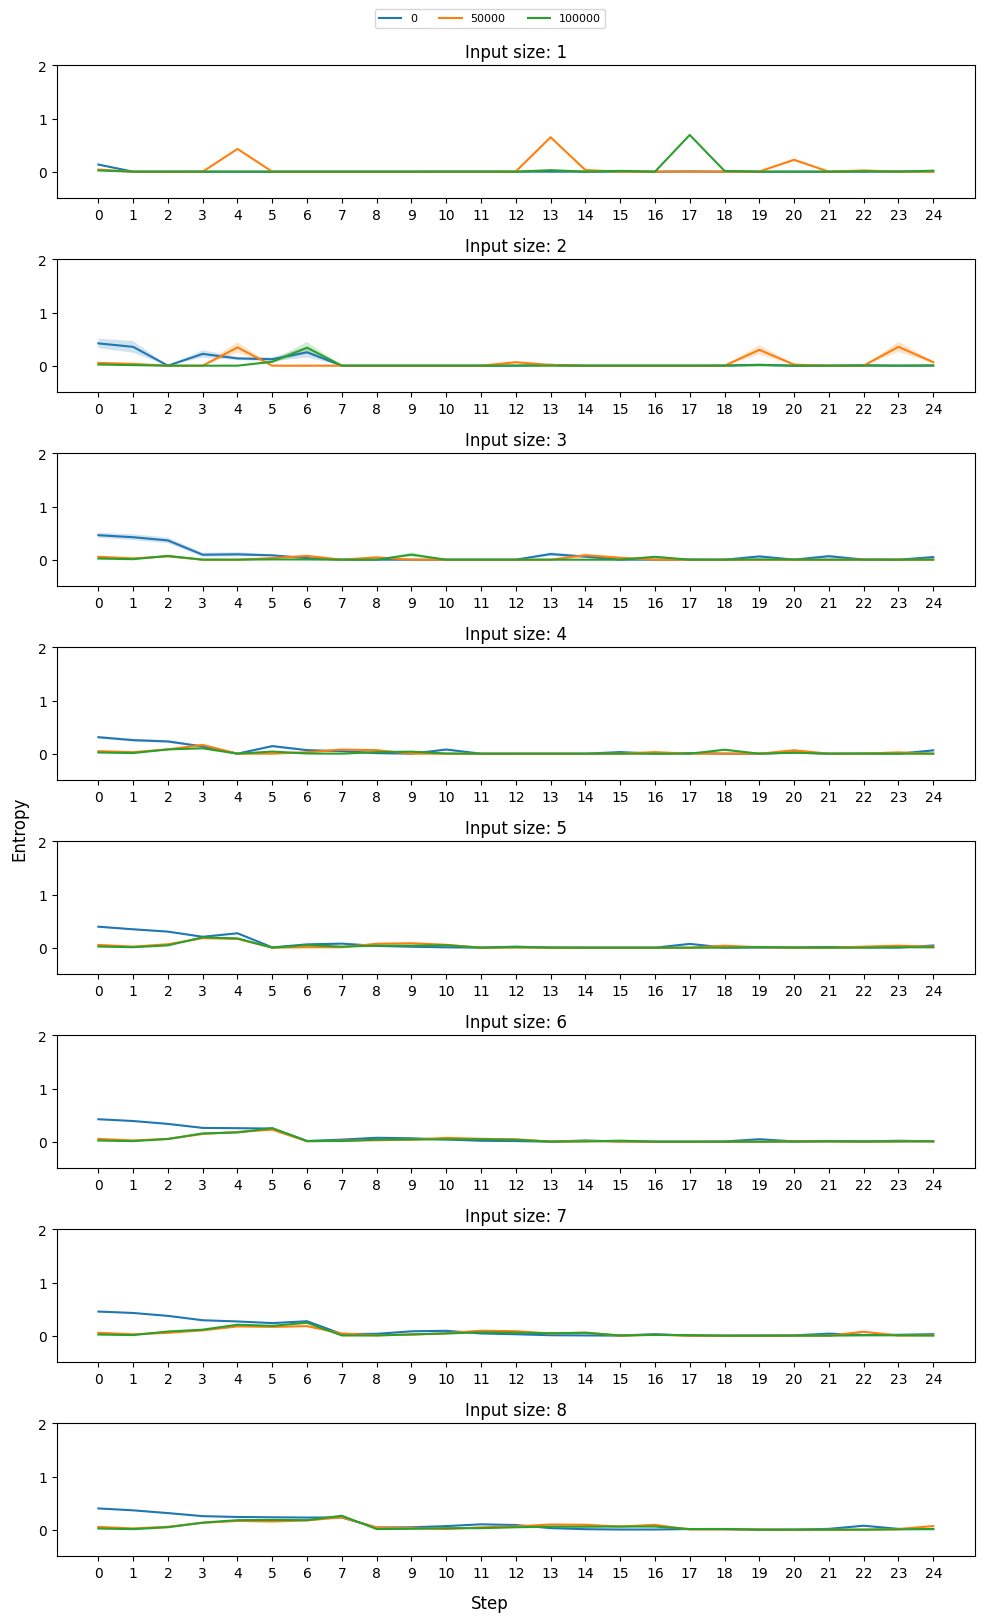

In [9]:
skip_step = 10
max_x = min(max_decode_len, 25)
checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(all_res["metrics"].keys()))

fig, axs = plt.subplots(
    len(all_res["results"][0]),
    1,
    figsize=(
        10,
        2 * len(all_res["results"][0])
    ),
)
for checkpoint_i in all_res["results"]:
    if (
        checkpoint_i != last_checkpoint
        and checkpoint_i > 0
        and checkpoint_i % skip_step != 0
    ):
        continue

    for plot_i, (input_size, curr_res) in enumerate(all_res["results"][checkpoint_i].items()):
        logits = curr_res["logits"][..., 1:, :]
        logits = logits.reshape((-1, *logits.shape[1:]))
        entropies = optax.softmax_cross_entropy(logits, jax.nn.softmax(logits, axis=-1))
        mean_entropy = jnp.mean(entropies, axis=0)[:max_x]
        std_entropy = (jnp.std(entropies, axis=0) / np.sqrt(len(entropies)))[:max_x]

        x_range = np.arange(len(mean_entropy))
        axs[plot_i].plot(
            x_range,
            mean_entropy,
            label=f"{checkpoint_i * checkpoint_interval}" if plot_i == 0 else "",
        )
        axs[plot_i].fill_between(
            x_range,
            mean_entropy - std_entropy,
            mean_entropy + std_entropy,
            alpha=0.2,
        )

        axs[plot_i].set_title(f"Input size: {input_size}")
        axs[plot_i].set_xticks(x_range)
        axs[plot_i].set_ylim(-0.5, 2.0)

fig.supylabel('Entropy')
fig.supxlabel('Step')
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)
plt.tight_layout()